# **Case Study: Predicting Apartment Prices from Layout Characteristics**

# **STAGE 1 : EXPLORATORY DATA ANALYSIS (EDA)**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Settings
sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)
# pd.reset_option('display.max_columns')

In [2]:
# Load dataset
df_raw = pd.read_csv('data/case_data.csv')

# Create a copy of the dataframe
df = df_raw.copy()

In [3]:
# Check the first few rows of the dataset
df.head()

,District,Address,Class,HouseNumber,Building,Plot,FloorsTotal,HandoverDate,Phase,BuildingType,InstallmentUntil,InstallmentMonths,Number,PIBNumber,LayoutType,Axis,Floor,Section,PropertyType,PropertyCategory,Apartments,Finishing,Status,ApartmentOption,Mortgage,Subsidies,Layout,CeilingHeight,TotalArea,AreaWithoutBalcony,LivingArea,KitchenArea,HallwayArea,BathroomArea,BalconyArea,PlotArea,PricePerMeter,TotalCost,Developer_encoded,Complex_encoded
0,МО Ленинский г.о.,"Сапроново д., Калиновая ул.",Комфорт,NaN,1,NaN,25,Сдан,1,Монолит,NaN,NaN,121,NaN,NaN,NaN,11,3,3 ккв,Многокв. дом,Нет,Чистовая,В продаже,Новостройка,Да,Нет,Да,2.8,76.1,74.1,43.7,12.2,13.5,"3,4с+1,3т","3,4л",0.0,266300.0,20265430.0,Developer58,Complex0
1,МО Ленинский г.о.,"Сапроново д., Калиновая ул.",Комфорт,NaN,1,NaN,25,Сдан,1,Монолит,NaN,NaN,144,NaN,NaN,NaN,16,3,3 ккв (Евро),Многокв. дом,Нет,Чистовая,В продаже,Новостройка,Да,Нет,Да,2.8,70.2,68.5,25.1,25.4,10.2,"3,4с+2т",3л,0.0,270900.0,19017180.0,Developer58,Complex0
2,МО Ленинский г.о.,"Сапроново д., Калиновая ул.",Комфорт,NaN,1,NaN,25,Сдан,1,Монолит,NaN,NaN,247,NaN,NaN,NaN,13,4,3 ккв,Многокв. дом,Нет,Чистовая,В продаже,Новостройка,Да,Нет,Да,2.8,77.9,75.8,43.9,13.4,13.6,"3,5с+1,4т","4,3б",0.0,264900.0,20635710.0,Developer58,Complex0
3,МО Ленинский г.о.,"Сапроново д., Калиновая ул.",Комфорт,NaN,1,NaN,25,Сдан,1,Монолит,NaN,NaN,153,NaN,NaN,NaN,19,3,3 ккв,Многокв. дом,Нет,Чистовая,В продаже,Новостройка,Да,Нет,Да,2.8,76.1,74.1,43.7,12.2,13.5,"3,4с+1,3т","3,4л",0.0,267300.0,20341530.0,Developer58,Complex0
4,МО Ленинский г.о.,"Сапроново д., Калиновая ул.",Комфорт,NaN,1,NaN,25,Сдан,1,Монолит,NaN,NaN,296,NaN,NaN,NaN,20,4,3 ккв,Многокв. дом,Нет,Чистовая,В продаже,Новостройка,Да,Нет,Да,2.8,77.9,75.8,43.9,13.4,13.6,"3,5с+1,4т","4,3б",0.0,266400.0,20752560.0,Developer58,Complex0


In [4]:
# Check the dataset information
from utils import check_data_information
check_data_information(df, cols=df.columns)

,Feature,Data Type,Null Values,Null Percentage,Zero Values,Zero Percentage,Negative Values,Negative Percentage,Empty Strings,Numeric in Object,Duplicated Values,Unique Values,Cardinality Ratio,Unique Sample
0,District,str,0,0.00,0,0.00,0,0.00,0,0,0,113,0.0019,"МО Ленинский г.о., Гольяново р-н, Молжаниновск..."
1,Address,str,0,0.00,0,0.00,0,0.00,0,0,0,323,0.0054,"Сапроново д., Калиновая ул., Москва г., Амурск..."
2,Class,str,0,0.00,0,0.00,0,0.00,0,0,0,4,0.0001,"Комфорт, Бизнес, Элит, Эконом"
3,HouseNumber,object,57660,97.22,0,0.00,0,0.00,0,830,0,31,0.0005,"nan, N, E, 1, 3"
4,Building,str,91,0.15,0,0.00,0,0.00,0,47827,0,507,0.0085,"1, 2, 4, 5, 3"
5,Plot,str,56249,94.84,0,0.00,0,0.00,0,967,0,49,0.0008,"nan, 1, 2, 3, 5"
6,FloorsTotal,int64,0,0.00,0,0.00,0,0.00,0,0,0,66,0.0011,"25, 24, 32, 15, 1"
7,HandoverDate,str,0,0.00,0,0.00,0,0.00,0,0,0,19,0.0003,"Сдан, 2026 г. 4 кв., 2027 г. 1 кв., 2027 г. 2 ..."
8,Phase,int64,0,0.00,0,0.00,0,0.00,0,0,0,28,0.0005,"1, 2, 3, 4, 5"
9,BuildingType,str,0,0.00,0,0.00,0,0.00,0,0,0,6,0.0001,"Монолит, Кирпич + Монолит, Панель, Монолит + П..."


In [5]:
# Checking shape of dataframe
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns {df.shape[1]}')

Number of rows: 59310
Number of columns 40


Initial preprocessing steps to do:

1. Drop the columns with large percentage of missing values:
    - `HouseNumber`, `Plot`, `InstallmentUntil`, `InstallmentMonths`, `PIBNumber`, `LayoutType`, `Axis`
2. Drop the rows with negative values in some columns where the values are not possible (only for column: `Floor`)
3. Drop columns with anomalie values: 
    - `PlotArea`
    - `Status`
4. Handle numerical columns with string values

Checking available columns based on requirements:
- number of rooms: ✅
- total area:
- floor and total number of floors:
- geographical localtion:
- additional apartment attributes:

In [6]:
# Define features and target
target = 'TotalCost'

# Numerical features
numerical_features = [
    'FloorsTotal', 'Phase', 'Floor',
    'CeilingHeight', 'TotalArea', 'AreaWithoutBalcony',
    'LivingArea', 'KitchenArea', 'HallwayArea'
]

# Categorical features
categorical_features = [
    'Class', 'BuildingType', 'PropertyType',
    'PropertyCategory', 'Apartments', 'Finishing',
    'ApartmentOption', 'Mortgage', 'Subsidies', 'Layout'
]

print(f"Target: {target}")
print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Filter out the columns based on findings in data information
df = df[numerical_features + categorical_features + [target]]

Target: TotalCost
Numerical features: 9
Categorical features: 10


Note: for features add more of geographical features later.

## Univariate Analysis

### Numerical Features

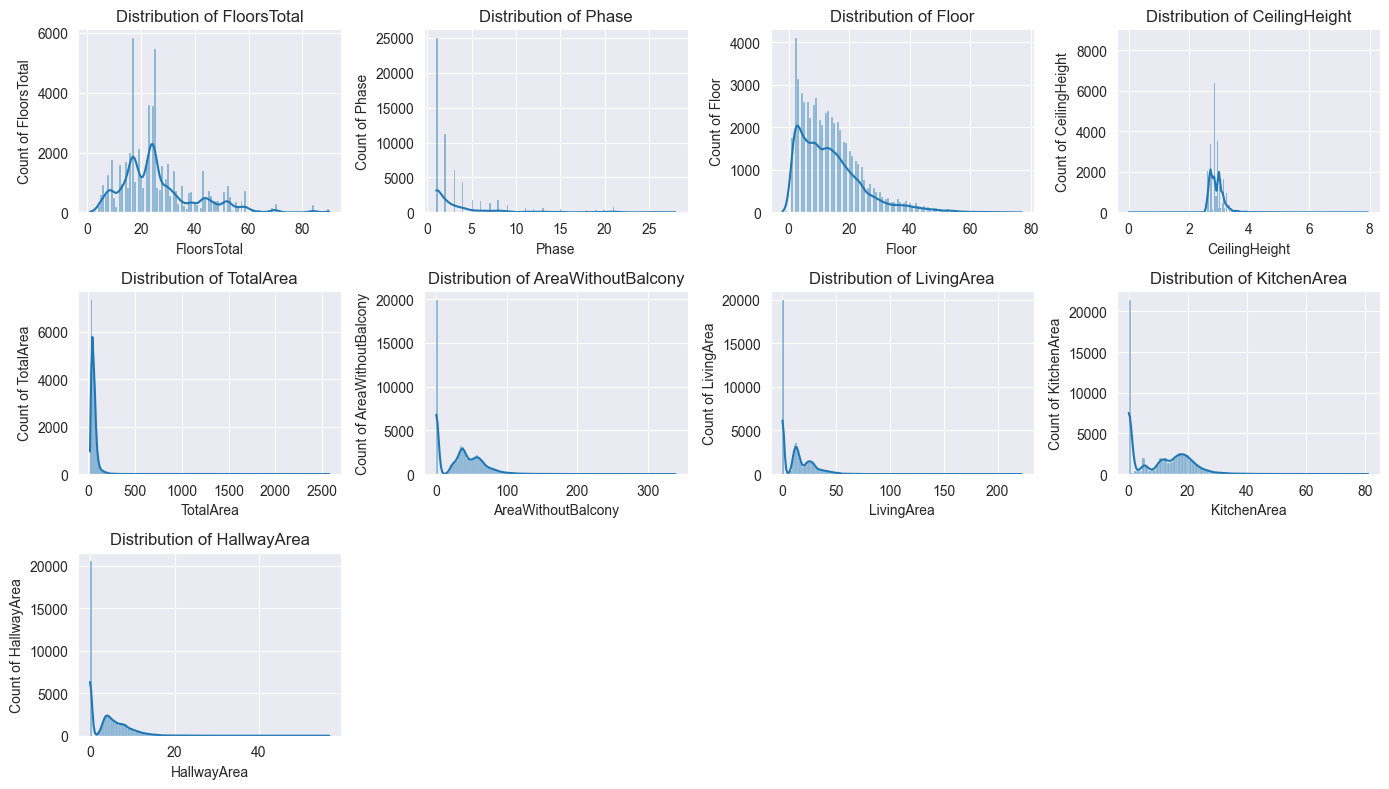

,Feature,overall_count,overall_mean,overall_std,overall_min,overall_25%,overall_50%,overall_75%,overall_max,overall_range,overall_IQR,overall_CV,overall_skewness,overall_kurtosis
0,FloorsTotal,59310.0,25.885854,13.887980,1.00,17.00,24.00,31.00,90.00,89.00,14.00,53.650846,1.232002,1.960952
1,Phase,59310.0,3.717012,4.694703,1.00,1.00,2.00,4.00,28.00,27.00,3.00,126.303131,2.660747,7.368455
2,Floor,59310.0,13.929253,10.700287,-2.00,6.00,12.00,19.00,77.00,79.00,13.00,76.818811,1.343070,2.273952
3,CeilingHeight,59310.0,2.942427,0.357592,0.00,2.73,2.85,3.02,7.95,7.95,0.29,12.152954,4.884894,47.053118
4,TotalArea,59310.0,60.166024,60.562978,16.88,37.90,52.00,68.60,2575.60,2558.72,30.70,100.659765,20.505493,594.172644
5,AreaWithoutBalcony,59310.0,33.657707,29.558089,0.00,0.00,35.50,54.90,339.50,339.50,54.90,87.819677,0.609190,0.802307
6,LivingArea,59310.0,14.337860,14.035079,0.00,0.00,12.70,23.50,222.40,222.40,23.50,97.888246,1.378936,6.546446
7,KitchenArea,59310.0,10.426443,9.606334,0.00,0.00,11.00,18.20,81.10,81.10,18.20,92.134339,0.474949,-0.174241
8,HallwayArea,59310.0,4.416951,4.226414,0.00,0.00,4.10,7.10,56.62,56.62,7.10,95.686220,1.050524,3.286216


In [7]:
# Checking the distribution and statistical summary of the numerical values
from utils import plot_dynamic_hisplots_kdeplots, describe_numerical_combined
plot_dynamic_hisplots_kdeplots(df=df, col_series=numerical_features, ncols=4, figsize=(14, 8))

# Display the overall statistics for numerical columns
numerical_summary = describe_numerical_combined(df, numerical_features)
display(numerical_summary)

### Categorical Features

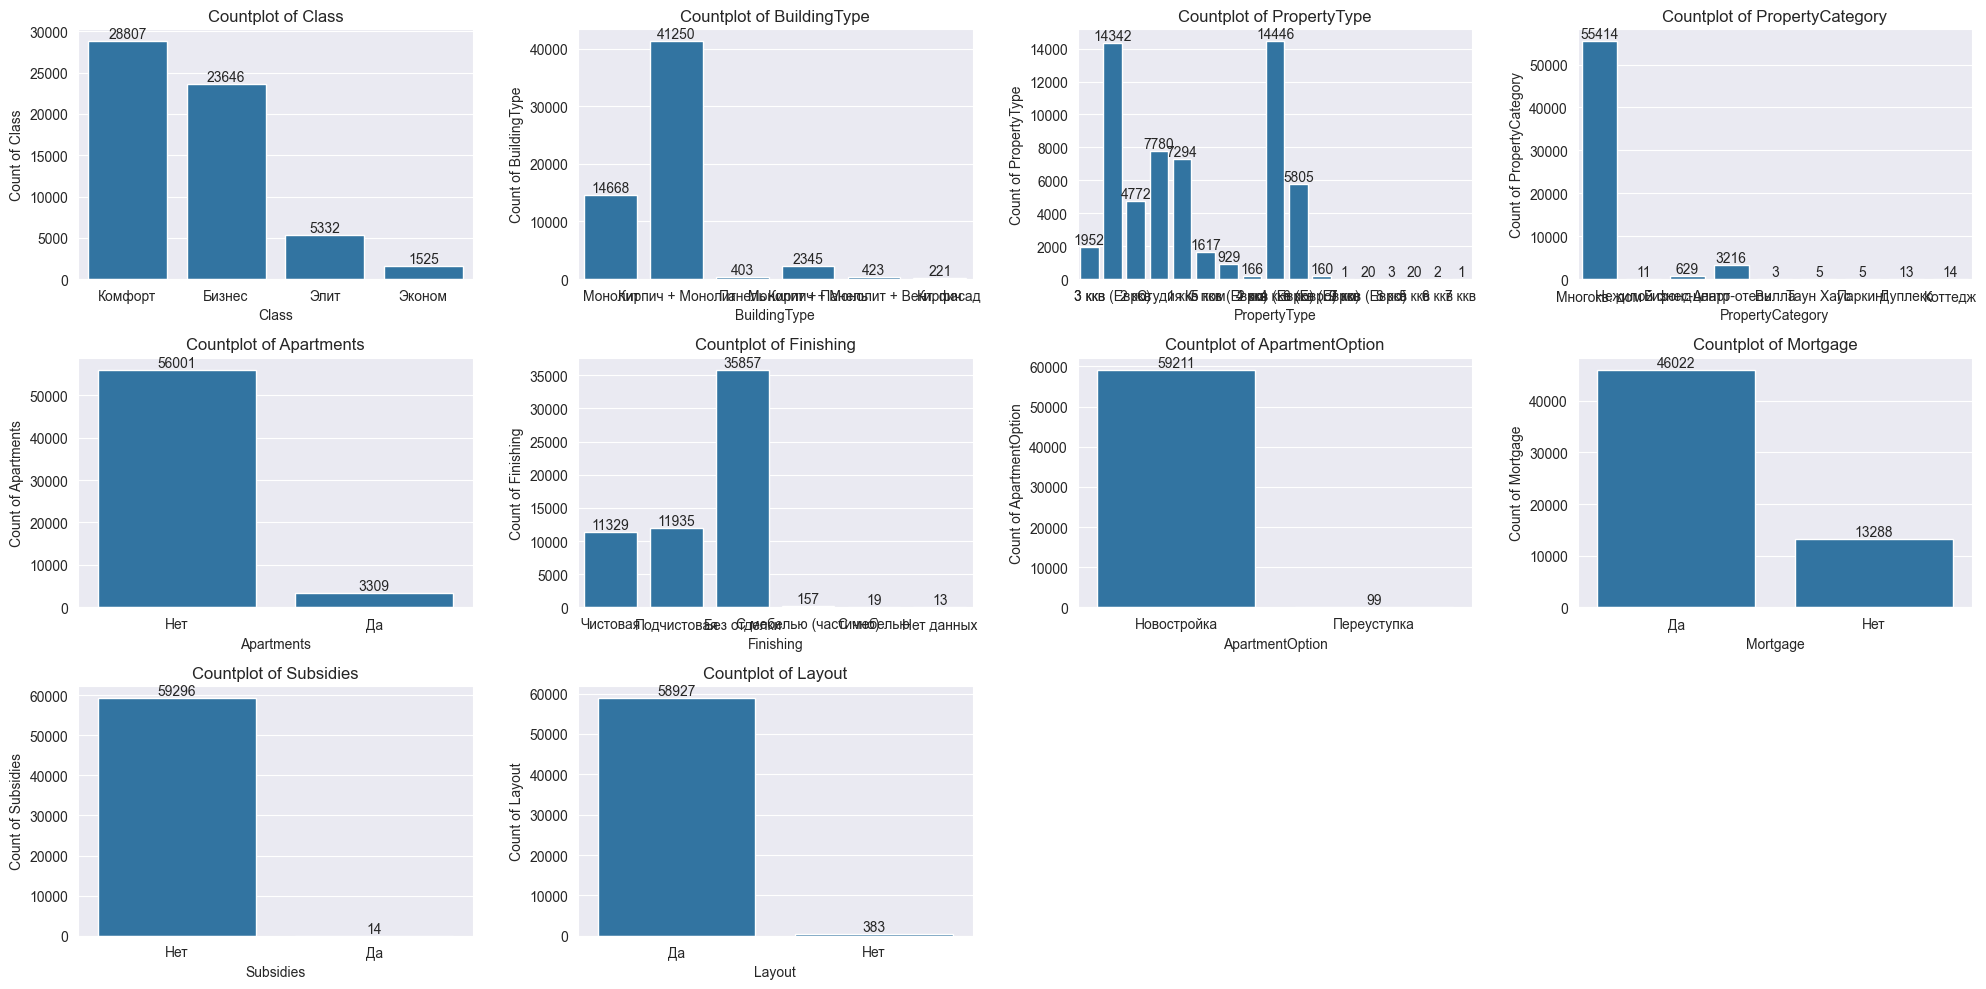

,Feature,overall_count,overall_unique,overall_top,overall_freq,overall_bottom,overall_freq_bottom,overall_top_percentage,overall_bottom_percentage,overall_n_categories
0,Class,59310,4,Комфорт,28807,Эконом,1525,48.57,2.57,4
1,BuildingType,59310,6,Кирпич + Монолит,41250,Кирпич,221,69.55,0.37,6
2,PropertyType,59310,17,2 ккв (Евро),14446,9 ккв,1,24.36,0.00,17
3,PropertyCategory,59310,9,Многокв. дом,55414,Вилла,3,93.43,0.01,9
4,Apartments,59310,2,Нет,56001,Да,3309,94.42,5.58,2
5,Finishing,59310,6,Без отделки,35857,Нет данных,13,60.46,0.02,6
6,ApartmentOption,59310,2,Новостройка,59211,Переуступка,99,99.83,0.17,2
7,Mortgage,59310,2,Да,46022,Нет,13288,77.60,22.40,2
8,Subsidies,59310,2,Нет,59296,Да,14,99.98,0.02,2
9,Layout,59310,2,Да,58927,Нет,383,99.35,0.65,2


In [8]:
# Checking the distribution and statistical summary of the categorical values
from utils import describe_categorical_combined, plot_dynamic_countplot

# Countplot function implementation
plot_dynamic_countplot(df=df, col_series=[col for col in categorical_features], ncols=4, figsize=(20, 10))

# Display the overall statistics for categorical columns
categorical_summary = describe_categorical_combined(df, categorical_features)
display(categorical_summary)

## Bivariate/Multivariate Analysis

<Figure size 1500x1500 with 0 Axes>

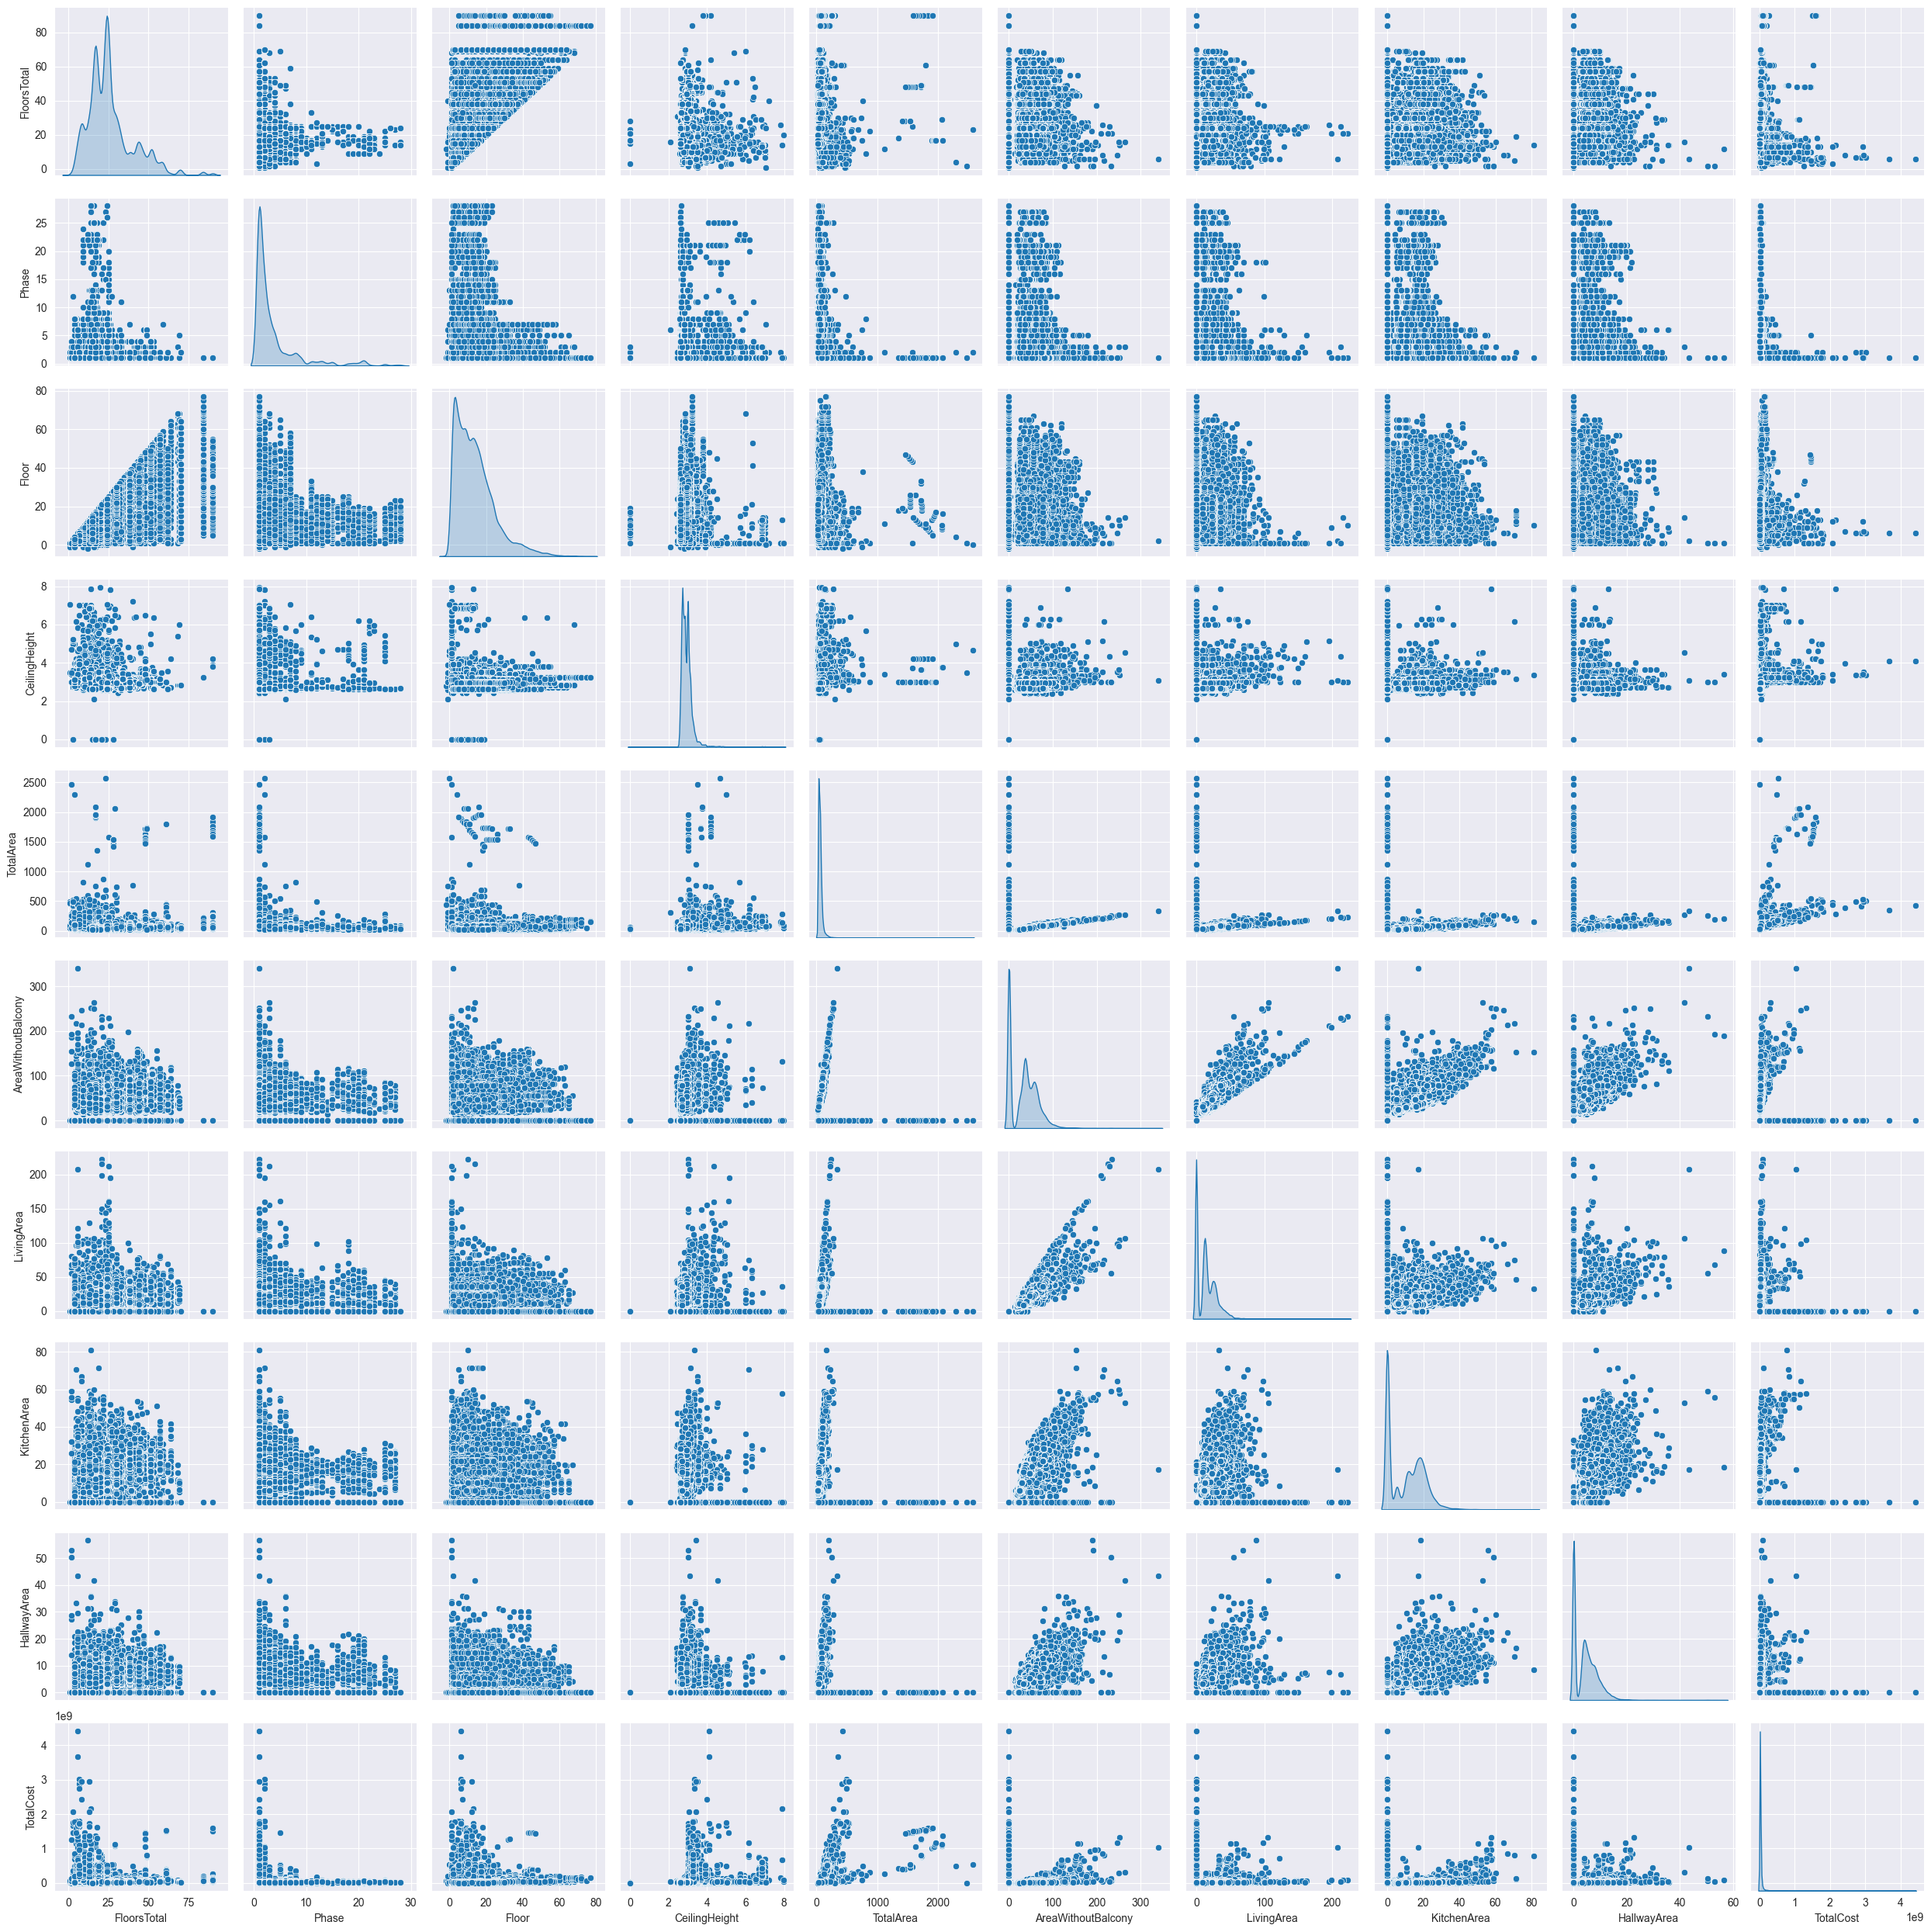

In [23]:
# Checking pairplot
plt.figure(figsize=(15, 15))
sns.pairplot(data=df, diag_kind='kde')
plt.tight_layout()
plt.show()

We will try further inspection using correlation heatmap for using Spearmann and Kendall method based on the pairplot result.

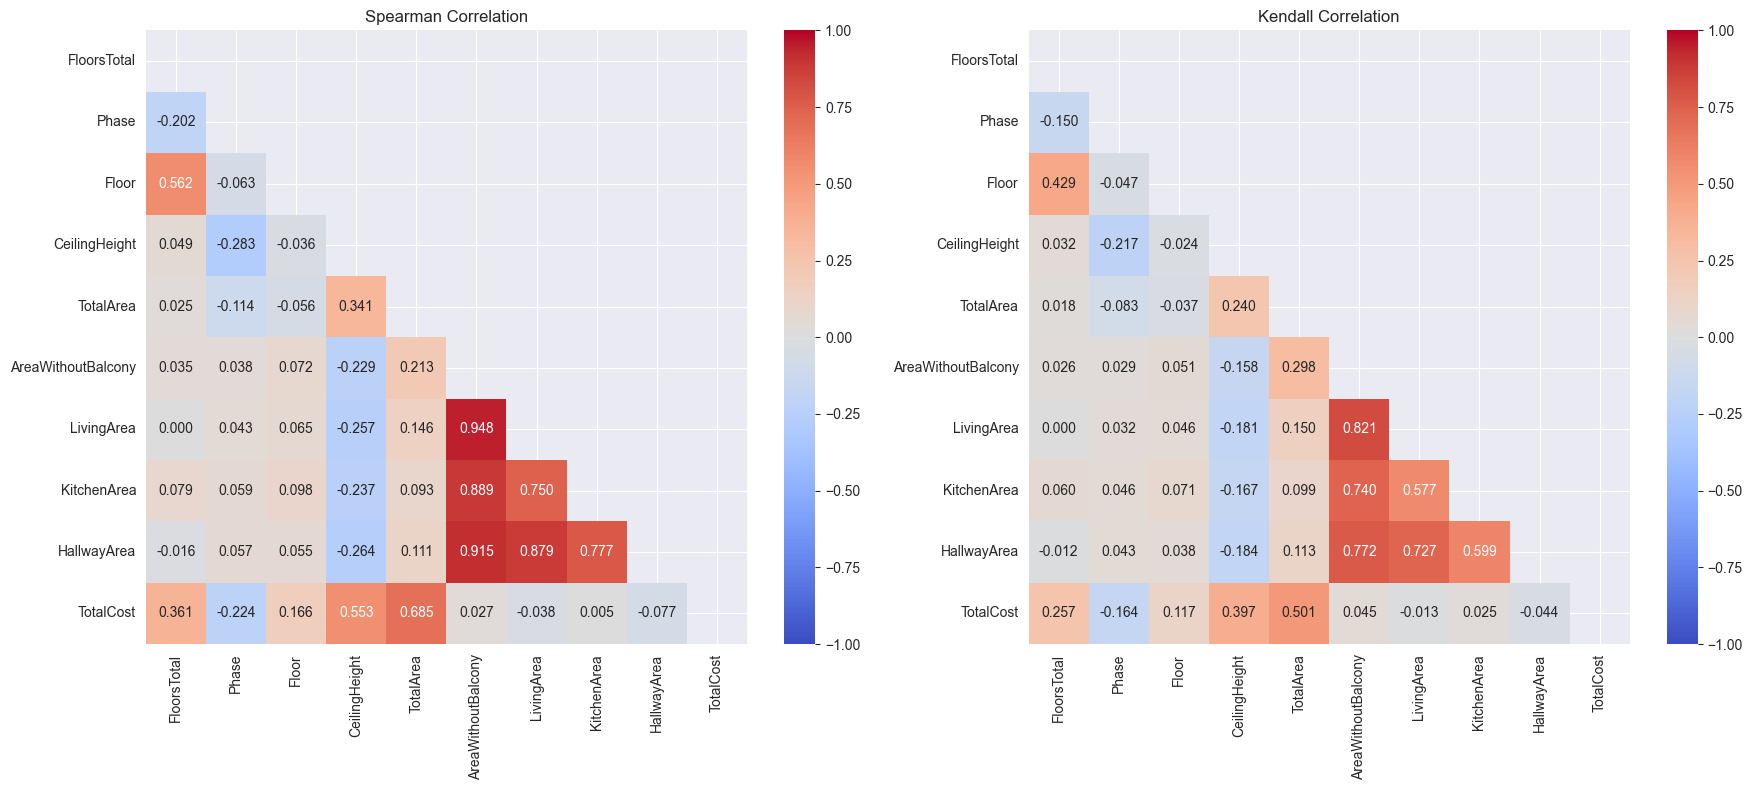

In [9]:
# Correlation heatmap of numerical features and target
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool))

# Plot correlation heatmap with Spearman method
sns.heatmap(data=df.corr(method='spearman', numeric_only=True), mask=mask, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title('Spearman Correlation')

# Plot correlation heatmap with Kendall method
sns.heatmap(data=df.corr(method='kendall', numeric_only=True), mask=mask, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title('Kendall Correlation')

plt.tight_layout()
plt.show()

# **STAGE 2 : DATA PRE-PROCESSING**

In [10]:
# Drop leftover missing rows
df = df.dropna(subset=[target]).copy()

# Remove rows that are not supposed to have negative values
df = df[df['Floor'] >= 0]

In [11]:
# Checking shape of dataframe after initial preprocessing
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns {df.shape[1]}')

Number of rows: 59282
Number of columns 20


In [1]:
# # Filter out rows where any of the check_outliers_cols contain non-numeric values
# # First, create a copy to avoid modifying the original dataframe
# df_filtered = df_raw.copy()

# # Convert columns to numeric, identifying non-numeric values
# for col in check_outliers_cols:
#     if col in df_filtered.columns:
#         # Convert to numeric, coercing errors to NaN
#         df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# # Drop rows with NaN values in these columns (which were non-numeric strings)
# df_filtered = df_filtered.dropna(subset=check_outliers_cols)

# # Update df_raw with the filtered data
# df_raw = df_filtered.copy()

# # Display the filtered dataframe
# df_raw[check_outliers_cols]

### Handling Outliers

Amount of Rows: 59282
Amount of Outlier Rows (Across All Columns): 16036
Amount of Non-Outlier Rows (Across All Columns): 43246
Percentage of Outliers: 27.05%



,Column Name,Outlier Exist,Lower Limit,Upper Limit,Outlier Data,Non-Outlier Data,Outlier Percentage (%)
0,FloorsTotal,True,-4.000000e+00,5.200000e+01,3115,56167,5.25
1,Phase,True,-3.500000e+00,8.500000e+00,6164,53118,10.40
2,Floor,True,-1.350000e+01,3.850000e+01,2289,56993,3.86
3,CeilingHeight,True,2.295000e+00,3.455000e+00,2240,57042,3.78
4,TotalArea,True,-8.150000e+00,1.146500e+02,2817,56465,4.75
5,AreaWithoutBalcony,True,-8.238375e+01,1.373062e+02,196,59086,0.33
6,LivingArea,True,-3.525000e+01,5.875000e+01,362,58920,0.61
7,KitchenArea,True,-2.730000e+01,4.550000e+01,114,59168,0.19
8,HallwayArea,True,-1.065000e+01,1.775000e+01,338,58944,0.57
9,TotalCost,True,-1.510560e+07,6.199818e+07,4738,54544,7.99


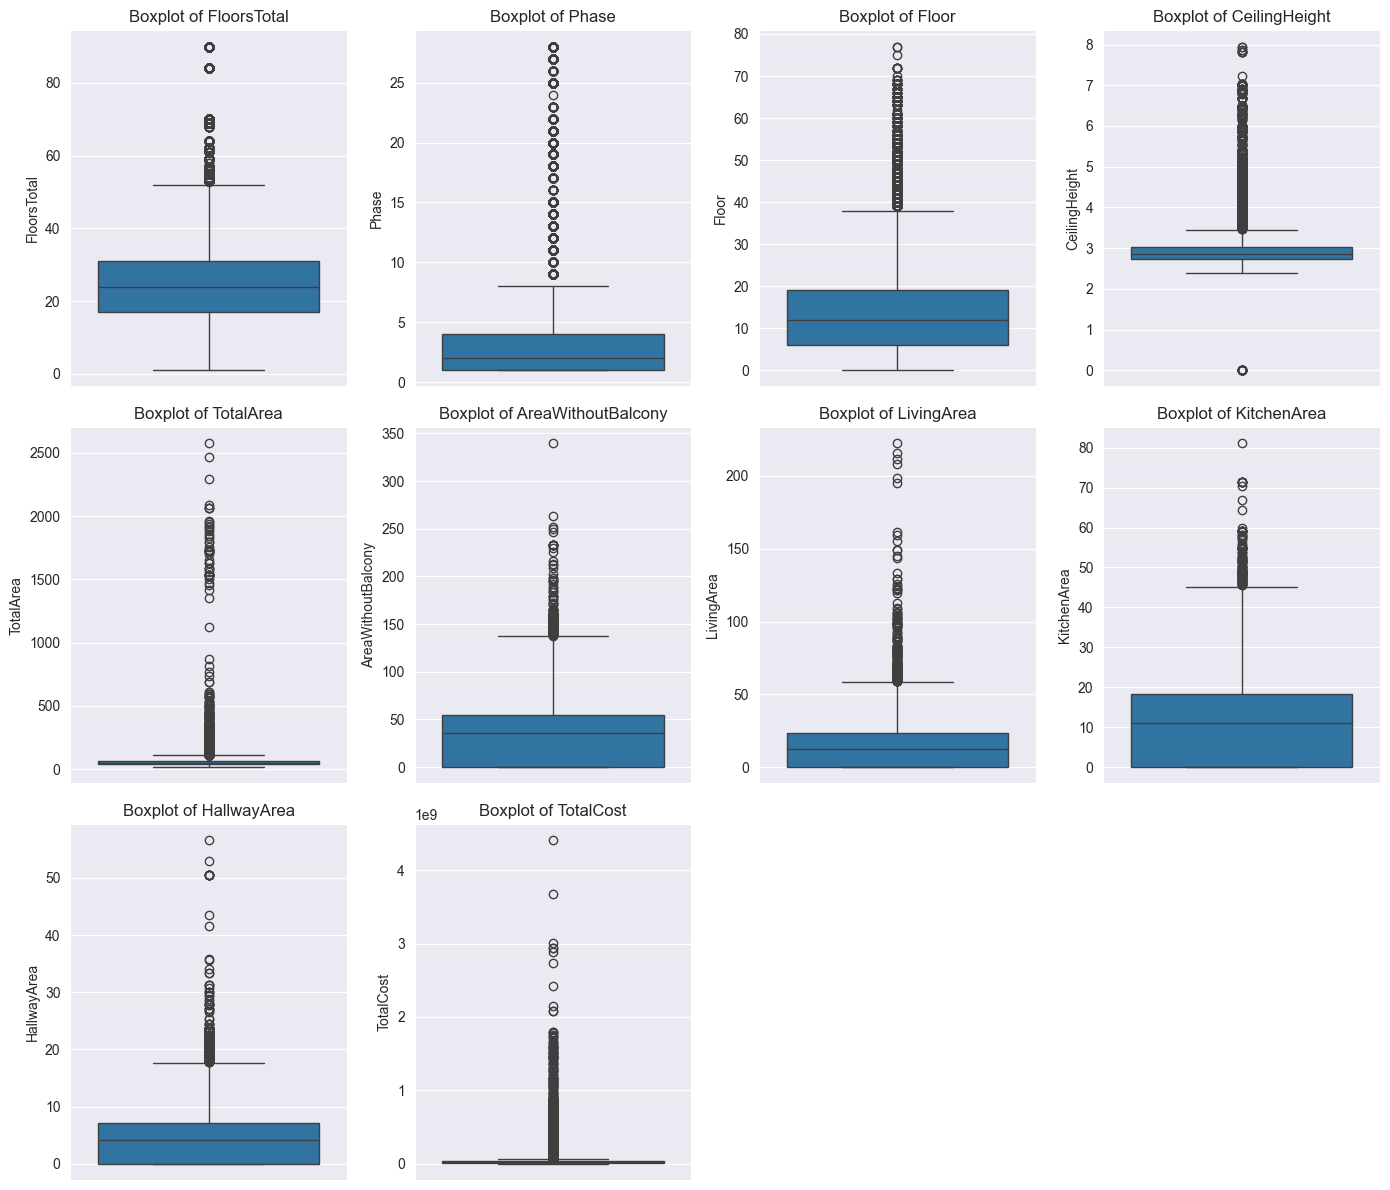

In [12]:
# Checking the outlier of the dataset
from utils import plot_dynamic_boxplots_violinplots, filter_outliers

# Check the outliers with IQR
check_outliers_cols = list(numerical_features) + ['TotalCost'] if 'TotalCost' not in numerical_features else numerical_features
summary = filter_outliers(df, columns=check_outliers_cols, detect_only=True)
display(summary)

# Visualize the outliers
plot_dynamic_boxplots_violinplots(df, check_outliers_cols, plot_type="boxplot", ncols=4, orientation="v", figsize=(14, 12))

In [13]:
# Implement the outliers handling
df = filter_outliers(df, columns=check_outliers_cols, method='iqr', threshold=1.5, detect_only=False)

### Feature Encoding

In [14]:
from utils import feature_encoding

df = feature_encoding(
    data=df,
    ordinal_columns=["Class", "Finishing"],
    nominal_columns=["BuildingType", "PropertyType", "PropertyCategory", "Apartments", 
                     "ApartmentOption", "Mortgage", "Subsidies", "Layout"],
    ordinal_categories={
        "Class": ["Эконом", "Комфорт", "Бизнес", "Элит"],
        "Finishing": ["Нет данных", "Без отделки", "Подчистовая", "Чистовая", "С мебелью (частично)", "С мебелью"]
    }
)

### Feature Selection

In [15]:
from utils import calculate_correlation_tabular

feature_feature_df, feature_target_df = calculate_correlation_tabular(df, target_col='TotalCost', method='spearman', corr_type='both')

Correlation Between Features:


,A,B,Corr Value,Corr Type
0,Apartments_Нет,PropertyCategory_Многокв. дом,0.944637,Positive
1,AreaWithoutBalcony,LivingArea,0.930278,Positive
2,BuildingType_Кирпич + Монолит,BuildingType_Монолит,0.924922,Negative
3,HallwayArea,AreaWithoutBalcony,0.898094,Positive
4,AreaWithoutBalcony,KitchenArea,0.870872,Positive
5,LivingArea,HallwayArea,0.849291,Positive
6,HallwayArea,KitchenArea,0.730917,Positive
7,KitchenArea,LivingArea,0.691789,Positive
8,PropertyCategory_Бизнес-центр,PropertyType_К. пом,0.671339,Positive
9,CeilingHeight,Class,0.653174,Positive



Correlation of Features to Target:


,Feature,Corr Value,Corr Type
0,Class,0.606217,Positive
1,TotalArea,0.598305,Positive
2,FloorsTotal,0.464143,Positive
3,CeilingHeight,0.449356,Positive
4,PropertyType_Студия,0.361496,Negative
5,PropertyType_3 ккв (Евро),0.337585,Positive
6,PropertyType_4 ккв (Евро),0.272843,Positive
7,Floor,0.198883,Positive
8,AreaWithoutBalcony,0.153056,Positive
9,KitchenArea,0.129034,Positive


In [16]:
from utils import calculate_feature_importance

feature_importance = calculate_feature_importance(
    X=df[[col for col in df.columns if col != "TotalCost"]], 
    y=df["TotalCost"], 
    task='regression', 
    method='f_regression', 
    k='all'
)
display(feature_importance.iloc[:20].reset_index(drop=True))

,Feature,Score,P_Values
0,TotalArea,25431.905725,0.000000e+00
1,Class,25186.447347,0.000000e+00
2,CeilingHeight,11173.394366,0.000000e+00
3,FloorsTotal,9484.028628,0.000000e+00
4,PropertyType_3 ккв (Евро),4951.824022,0.000000e+00
5,PropertyType_Студия,4914.110179,0.000000e+00
6,PropertyType_4 ккв (Евро),4826.220991,0.000000e+00
7,Floor,1916.584027,0.000000e+00
8,KitchenArea,595.911983,9.986827e-131
9,AreaWithoutBalcony,549.957626,7.327378e-121


In [17]:
from utils import calculate_feature_importance

feature_importance = calculate_feature_importance(
    X=df[[col for col in df.columns if col != "TotalCost"]], 
    y=df["TotalCost"], 
    task='regression', 
    method='mutual_info', 
    k='all'
)
display(feature_importance.iloc[:20].reset_index(drop=True))

,Feature,Score,P_Values
0,TotalArea,1.253998,None
1,AreaWithoutBalcony,1.007709,None
2,LivingArea,0.910337,None
3,KitchenArea,0.886230,None
4,HallwayArea,0.744383,None
5,FloorsTotal,0.655383,None
6,CeilingHeight,0.622320,None
7,Class,0.346536,None
8,Phase,0.211923,None
9,PropertyType_Студия,0.137888,None


In [22]:
# Select features for modelling
base_cols = ["TotalArea", "Class", "CeilingHeight", "FloorsTotal", "Phase", "Finishing"]
property_type_cols = [col for col in df.columns if col.startswith("PropertyType_")]
selected_cols = base_cols + property_type_cols

X = df[selected_cols]
y = df[target]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (43246, 15)
Target vector shape: (43246,)


### Data Splitting and Feature Scaling

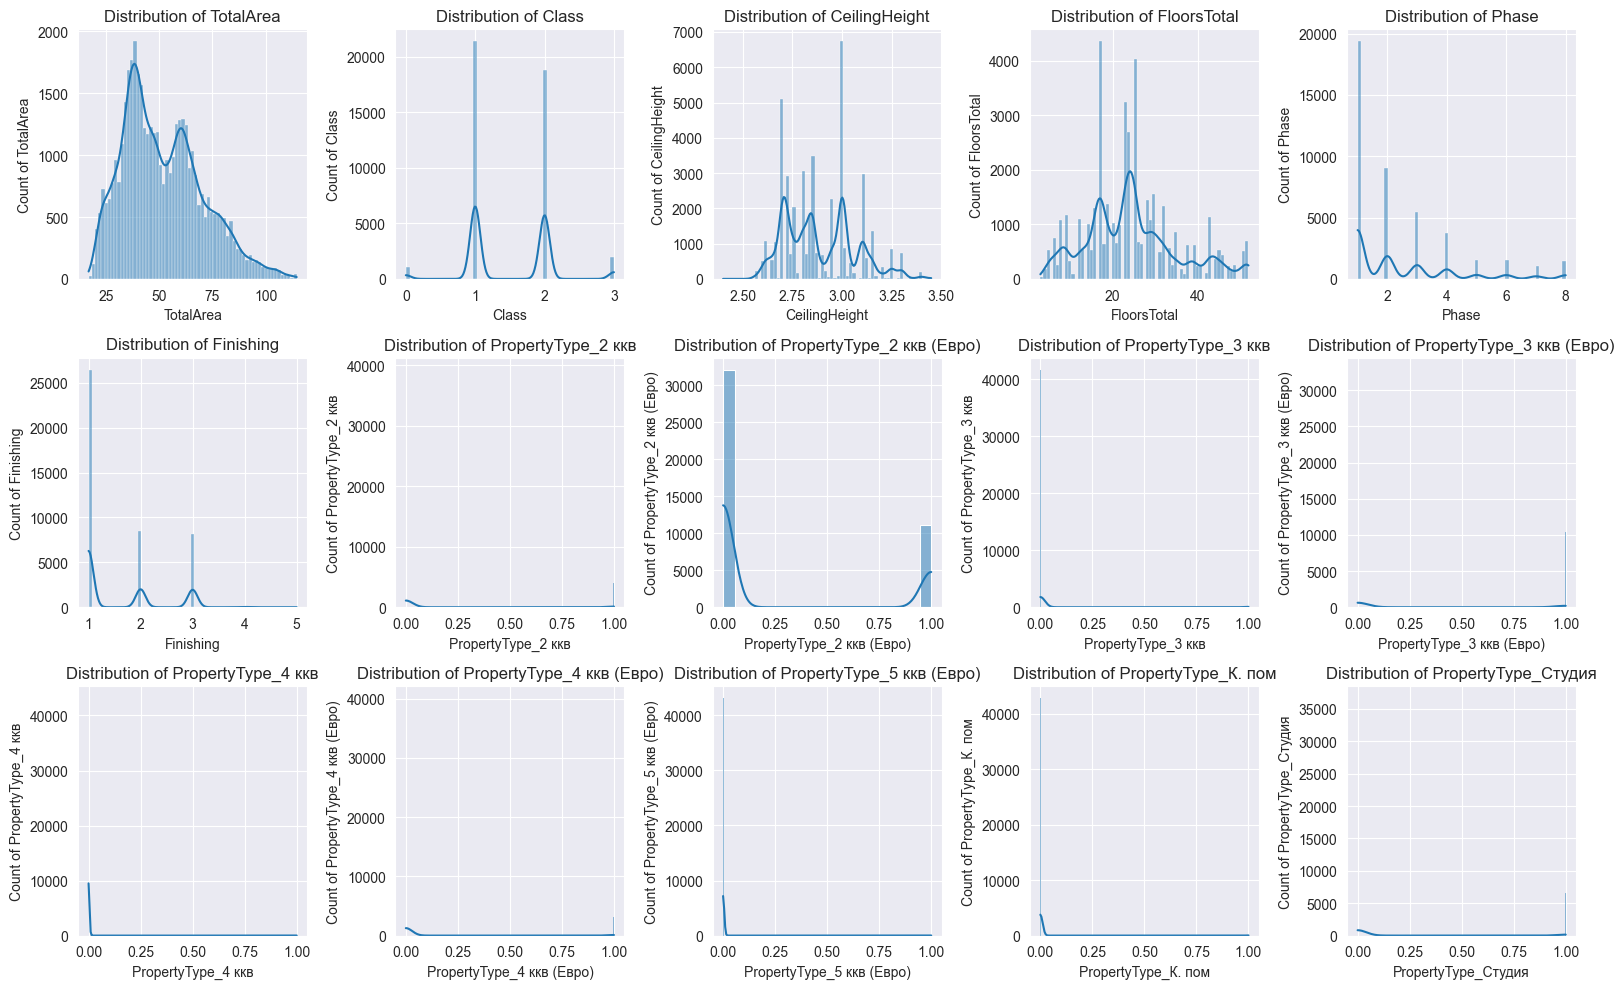

In [23]:
# Check distribution again before implementing scaling
plot_dynamic_hisplots_kdeplots(df=df, col_series=selected_cols, ncols=5, figsize=(16, 10))

In [24]:
from sklearn.model_selection import train_test_split

# Split the data into train (70%), validation (15%), and test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Apply scaling to the datasets
from utils import feature_scaling

# Fit on train data
X_train, scalers = feature_scaling(
    X_train,
    scaling_config={
        "minmax": {
            "columns": ["Class", "Phase", "Finishing"]
        },
        "standard": {
            "columns": ["CeilingHeight"]
        },
        "robust": {
            "columns": ["TotalArea", "FloorsTotal"],
            "apply_log": False
        }
    }
)

# Transform only validation and test data
X_test, _ = feature_scaling(
    X_test,
    scaling_config={
        "minmax": {
            "columns": ["Class", "Phase", "Finishing"]
        },
        "standard": {
            "columns": ["CeilingHeight"]
        },
        "robust": {
            "columns": ["TotalArea", "FloorsTotal"],
            "apply_log": False
        }
    },
    scaler=scalers
)

X_val, _ = feature_scaling(
    X_val,
    scaling_config={
        "minmax": {
            "columns": ["Class", "Phase", "Finishing"]
        },
        "standard": {
            "columns": ["CeilingHeight"]
        },
        "robust": {
            "columns": ["TotalArea", "FloorsTotal"],
            "apply_log": False
        }
    },
    scaler=scalers
)

print(f"\nTraining set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")


Training set: 30272 samples (70.0%)
Validation set: 6487 samples (15.0%)
Test set: 6487 samples (15.0%)


# **STAGE 3 : MODELLING AND EVALUATION**

## Train Vanilla Models

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Initiatialize object for each model and store in a iterable
lr = LinearRegression()
knn = KNeighborsRegressor()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)

models = [lr, knn, dt, rf, xgb]

# Train models
for model in models :
    model.fit(X_train, y_train)

## Evaluate Vanilla Models

In [26]:
from utils import eval_regression

### Linear Regression

In [27]:
metrics_vanilla_lr = eval_regression(model=lr,
                                    X_train=X_train,
                                    y_train=y_train,
                                    X_test=X_val,
                                    y_test=y_val)

Performance Metrics for LinearRegression:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  5004010.8679 ± 33822.9328
  Train: 4998951.0446 ± 9608.2352

MSE:
  Test:  43581528567324.9297 ± 585080327192.6239
  Train: 43489310631055.3984 ± 145017392401.4272

RMSE:
  Test:  6601481.9526 ± 44323.7691
  Train: 6594633.4056 ± 10994.3748

MAPE:
  Test:  299369062100403355648.00% ± 598741999129853296640.00%
  Train: 299869034334544461824.00% ± 149937928105865412608.00%

R2:
  Test:  0.6961 ± 0.0058
  Train: 0.6968 ± 0.0014

Single Run Metrics:

MAE:
  Test:  4998414.8342
  Train: 4999626.6764

MSE:
  Test:  43533910266220.9922
  Train: 43498486079284.2891

RMSE:
  Test:  6598023.2090
  Train: 6595338.2081

MAPE:
  Test:  27.11%
  Train: 299774573509493587968.00%

R2:
  Test:  0.6941
  Train: 0.6968


### K-Nearest Neighbours

In [28]:
metrics_vanilla_knn = eval_regression(model=knn,
                                     X_train=X_train,
                                     y_train=y_train,
                                     X_test=X_val,
                                     y_test=y_val)

Performance Metrics for KNeighborsRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  1532004.0059 ± 51622.1706
  Train: 1134583.4322 ± 9735.3657

MSE:
  Test:  10867980124780.9336 ± 943924244711.6296
  Train: 6293290420823.9111 ± 120054218874.3075

RMSE:
  Test:  3293609.3045 ± 141837.4918
  Train: 2508529.2022 ± 23909.4699

MAPE:
  Test:  114370200929806483456.00% ± 228740695930853982208.00%
  Train: 91071484277322465280.00% ± 45536132044060073984.00%

R2:
  Test:  0.9243 ± 0.0061
  Train: 0.9561 ± 0.0008

Single Run Metrics:

MAE:
  Test:  1366488.1916
  Train: 1013522.7783

MSE:
  Test:  8622608575829.7529
  Train: 5303507743871.6230

RMSE:
  Test:  2936427.8598
  Train: 2302934.5939

MAPE:
  Test:  5.73%
  Train: 90833700729629032448.00%

R2:
  Test:  0.9394
  Train: 0.9630


### Decision Tree

In [29]:
metrics_vanilla_dt = eval_regression(model=dt,
                                     X_train=X_train,
                                     y_train=y_train,
                                     X_test=X_val,
                                     y_test=y_val)

Performance Metrics for DecisionTreeRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  1136181.2884 ± 50543.4151
  Train: 197052.1506 ± 2185.1464

MSE:
  Test:  9053165088395.4961 ± 1123032334697.7830
  Train: 250443852923.3293 ± 9451448104.5672

RMSE:
  Test:  3003073.2261 ± 186323.0712
  Train: 500354.7368 ± 9433.4656

MAPE:
  Test:  113537125846042771456.00% ± 227074252552490188800.00%
  Train: 87048717091101229056.00% ± 43627066622075338752.00%

R2:
  Test:  0.9369 ± 0.0076
  Train: 0.9983 ± 0.0001

Single Run Metrics:

MAE:
  Test:  1034541.6381
  Train: 214110.7596

MSE:
  Test:  7583425361849.6885
  Train: 277879728385.9891

RMSE:
  Test:  2753801.9830
  Train: 527142.9867

MAPE:
  Test:  4.34%
  Train: 90833700729629032448.00%

R2:
  Test:  0.9467
  Train: 0.9981


#### Random Forest

In [30]:
metrics_vanilla_rf = eval_regression(model=rf,
                                    X_train=X_train,
                                    y_train=y_train,
                                    X_test=X_val,
                                    y_test=y_val)

Performance Metrics for RandomForestRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  1084285.3903 ± 37209.2911
  Train: 495703.8958 ± 2072.6916

MSE:
  Test:  5771381393129.0322 ± 595845663795.2041
  Train: 993350368823.6775 ± 14068747654.0316

RMSE:
  Test:  2399116.0718 ± 124993.8690
  Train: 996644.6837 ± 7052.8852

MAPE:
  Test:  113782907870826414080.00% ± 227566750445568720896.00%
  Train: 88768221641093873664.00% ± 44626664180557144064.00%

R2:
  Test:  0.9598 ± 0.0039
  Train: 0.9931 ± 0.0001

Single Run Metrics:

MAE:
  Test:  969642.9894
  Train: 468938.7826

MSE:
  Test:  4513597313365.3037
  Train: 900423313548.5352

RMSE:
  Test:  2124522.8437
  Train: 948906.3777

MAPE:
  Test:  4.13%
  Train: 91842819550543708160.00%

R2:
  Test:  0.9683
  Train: 0.9937


### XGBoost

In [31]:
metrics_vanilla_xgb = eval_regression(model=xgb,
                                    X_train=X_train,
                                    y_train=y_train,
                                    X_test=X_val,
                                    y_test=y_val)

Performance Metrics for XGBRegressor:

Cross-Validated Metrics (mean ± std):

MAE:
  Test:  1667707.0584 ± 23888.8212
  Train: 1450080.7532 ± 22796.1772

MSE:
  Test:  7814120955326.2744 ± 377406383032.9405
  Train: 5667940666134.7832 ± 206628981031.9196

RMSE:
  Test:  2794558.0897 ± 67572.4680
  Train: 2380347.2348 ± 43447.7605

MAPE:
  Test:  121846336511026429952.00% ± 243940884838848659456.00%
  Train: 114165581205112569856.00% ± 57565909256463425536.00%

R2:
  Test:  0.9455 ± 0.0022
  Train: 0.9605 ± 0.0015

Single Run Metrics:

MAE:
  Test:  1681938.6761
  Train: 1505262.4617

MSE:
  Test:  7569001978496.4746
  Train: 6155061983622.2139

RMSE:
  Test:  2751181.9239
  Train: 2480939.7380

MAPE:
  Test:  7.93%
  Train: 124693399805707681792.00%

R2:
  Test:  0.9468
  Train: 0.9571


Based on the result, it could be said that the 2 best models are Random Forest and XGB.

1. RandomForestRegressor ⭐ BEST

- Test R²: 0.9635 (explains 96.35% of variance)
- Test RMSE: 2,272,116
- Test MAE: 1,012,232

Why it wins: Excellent generalization with minimal overfitting (gap between train/test metrics is reasonable), best test performance overall

2. XGBRegressor

- Test R²: 0.9557
- Test RMSE: 2,504,810
- Test MAE: 1,508,582

Why second: Strong performance with good generalization, slightly behind Random Forest but still excellent

## Hyperparameter Tuning

As for the hyperparameter tuning we will be doing it only to the best model which is random forest.

Processing Pipelines:   0%|          | 0/1 [00:00<?, ?it/s]


Validation curve for rf__n_estimators...
  rf__n_estimators=50: train=0.994, test=0.966
  rf__n_estimators=100: train=0.994, test=0.966
  rf__n_estimators=200: train=0.994, test=0.967


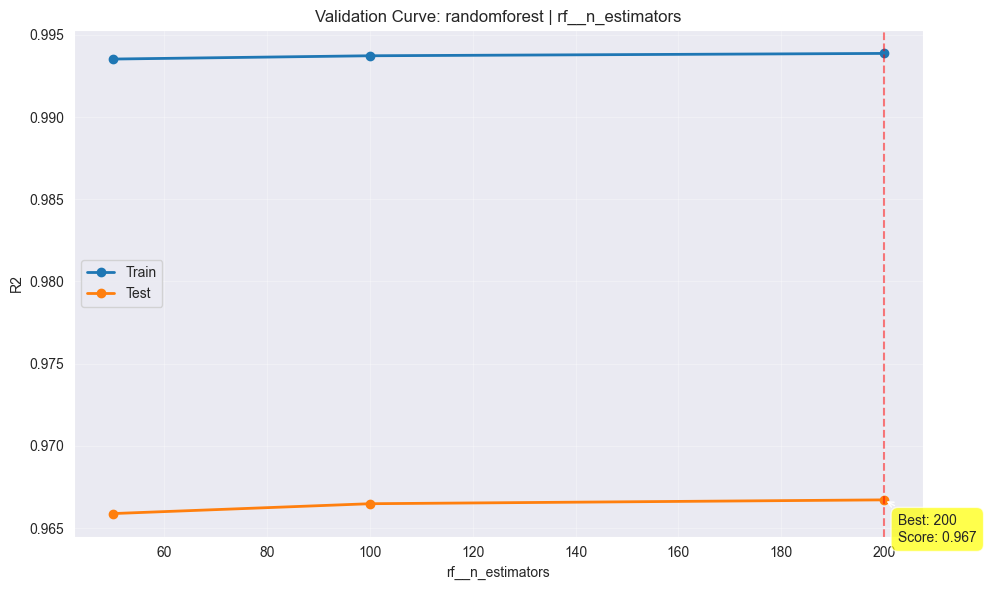


Validation curve for rf__criterion...
  rf__criterion=squared_error: train=0.994, test=0.966
  rf__criterion=friedman_mse: train=0.994, test=0.967
  rf__criterion=absolute_error: train=0.993, test=0.964


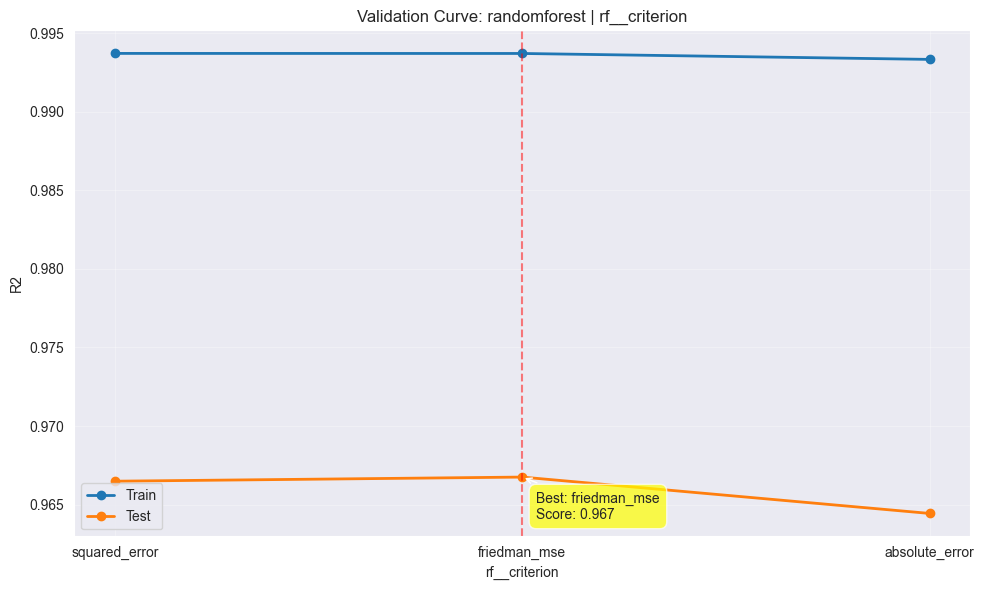


Validation curve for rf__max_depth...
  rf__max_depth=5: train=0.721, test=0.709
  rf__max_depth=10: train=0.892, test=0.879
  rf__max_depth=15: train=0.970, test=0.948
  rf__max_depth=20: train=0.990, test=0.965


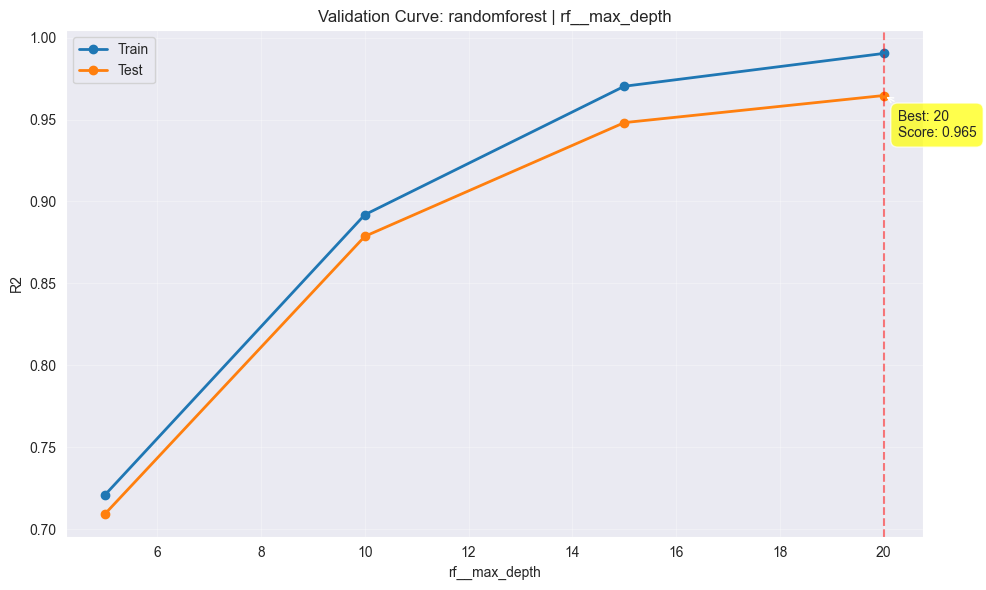


Validation curve for rf__min_samples_split...
  rf__min_samples_split=2: train=0.994, test=0.966
  rf__min_samples_split=5: train=0.990, test=0.965
  rf__min_samples_split=10: train=0.983, test=0.960


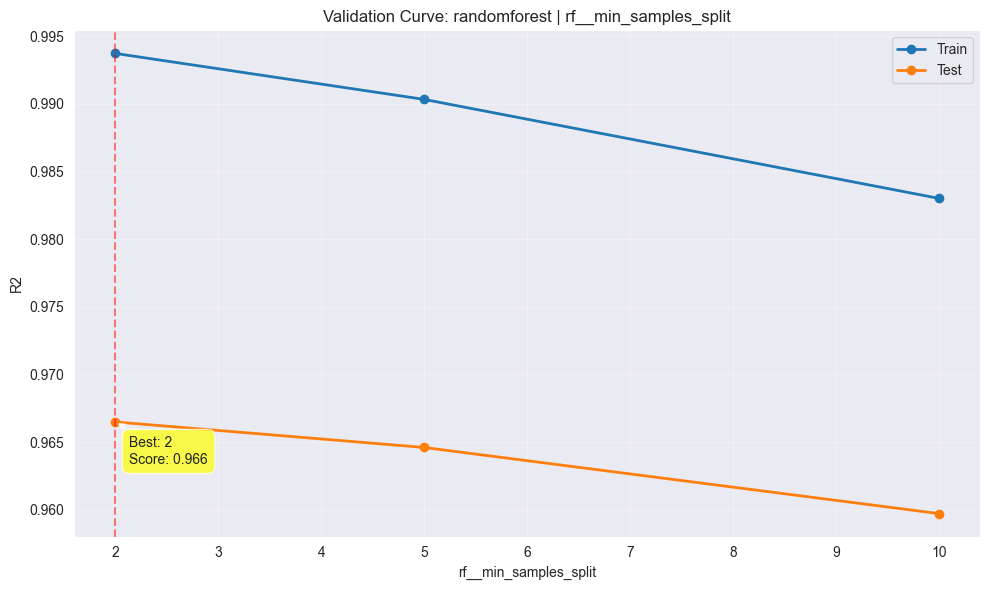


Validation curve for rf__max_features...
  rf__max_features=sqrt: train=0.994, test=0.967
  rf__max_features=log2: train=0.994, test=0.967


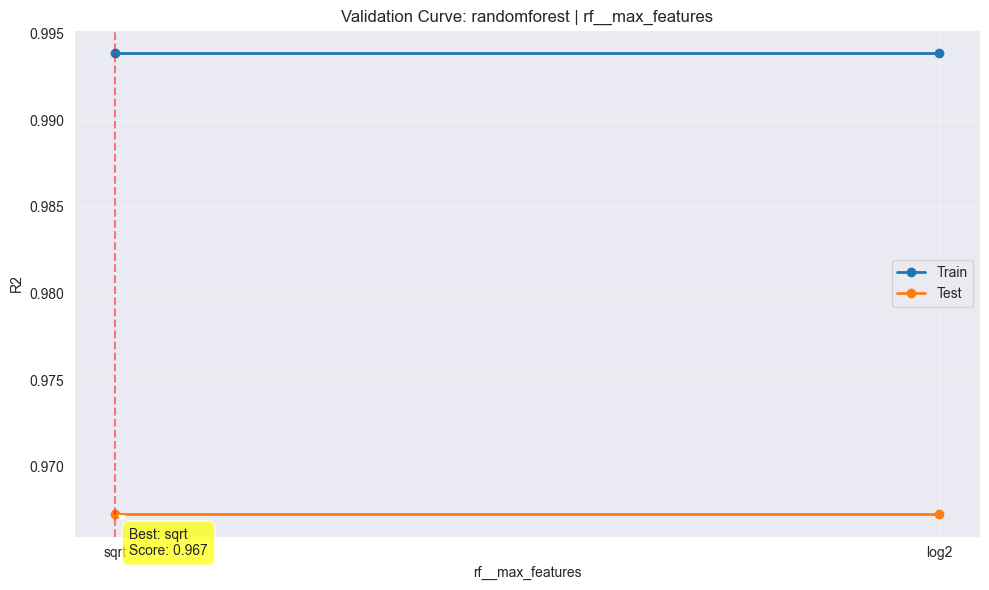


Validation curve for rf__min_samples_leaf...
  rf__min_samples_leaf=1: train=0.994, test=0.966
  rf__min_samples_leaf=2: train=0.986, test=0.961
  rf__min_samples_leaf=4: train=0.973, test=0.951


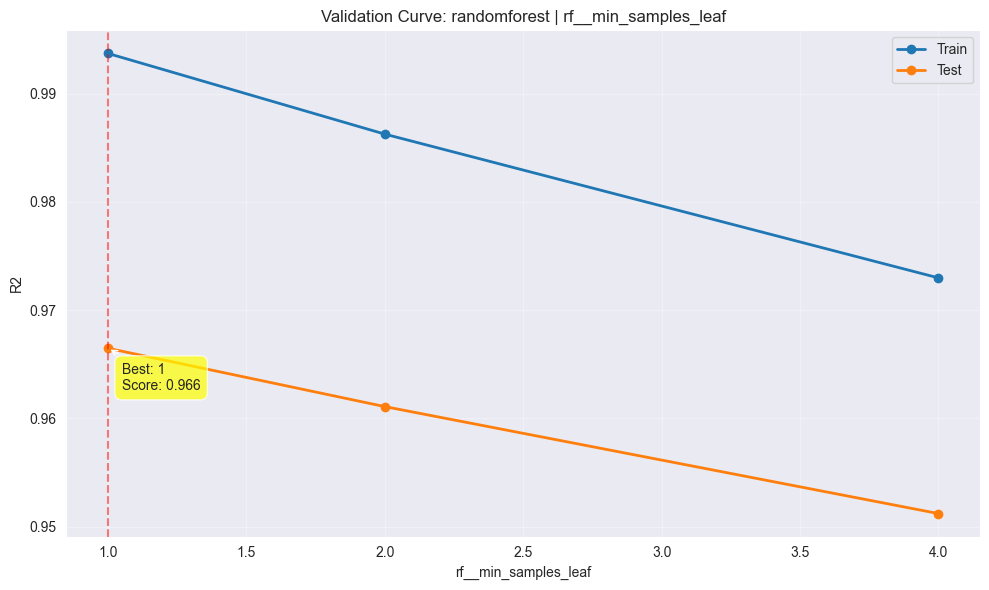

Validation Curves for randomforest: 100%|██████████| 6/6 [03:06<00:00, 31.06s/it]

Fitting 15 folds for each of 648 candidates, totalling 9720 fits



Processing Pipelines:   0%|          | 0/1 [11:21<?, ?it/s]


KeyboardInterrupt: 

In [32]:
from utils import tune_single_model

# Select models to tune
models_to_tune = "randomforest"

fitted_model, fit_time = tune_single_model(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name=models_to_tune,
    search_method='grid',
    n_iter=30,
    scoring='r2',
    display=True,
    progress_bar=True,
    plot_validation_curves=True
)

print(f'  Best CV Score: {fitted_model.best_score_:.4f}')
print(f'  Best Parameters: {fitted_model.best_params_}')

## Train Tuned Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(random_state=42, )
rf_tuned.fit(X_train, y_train)

## Evaluate Tuned Model

In [ ]:
metrics_tuned_rf = eval_regression(model=rf_tuned,
                                    X_train=X_train,
                                    y_train=y_train,
                                    X_test=X_val,
                                    y_test=y_val)

## Save Model Artifacts

In [ ]:
import joblib
import pickle
from pathlib import Path

# Create artifacts directory if it doesn't exist
artifacts_dir = Path('model_artifacts')
artifacts_dir.mkdir(exist_ok=True)

# Save the trained model using joblib (recommended for scikit-learn models)
model_path = artifacts_dir / 'rf_tuned_model.joblib'
joblib.dump(rf_tuned, model_path)
print(f'Model saved to: {model_path}')

# Alternative: Save using pickle
pickle_path = artifacts_dir / 'rf_tuned_model.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump(rf_tuned, f)
print(f'Model also saved to: {pickle_path}')

# Save feature names for future reference
feature_names_path = artifacts_dir / 'feature_names.joblib'
joblib.dump(X_train.columns.tolist(), feature_names_path)
print(f'Feature names saved to: {feature_names_path}')

# Save preprocessing pipeline if you have one
# joblib.dump(preprocessor, artifacts_dir / 'preprocessor.joblib')

# To load the model later:
# loaded_model = joblib.load('model_artifacts/rf_tuned_model.joblib')
# loaded_features = joblib.load('model_artifacts/feature_names.joblib')

---

In [ ]:
# Setting model comparison
comparison_results = []

for name, model in fitted_models.items():
    y_pred = model.best_estimator_.predict(X_test)
    
    # Calculate metrics
    from sklearn.metrics import mean_absolute_error, r2_score
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    comparison_results.append({
        'Model': name,
        'Best_CV_Score': model.best_score_,
        'Test_MAE': mae,
        'Test_R2': r2
    })
    
    print(f'\n{name.upper()}:')
    print(f'  Mean Absolute Error: {mae:,.0f}')
    print(f'  R2 Score: {r2:.4f}')

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_results)
print('\n' + '='*60)
print('COMPARISON TABLE')
print('='*60)
print(comparison_df.to_string(index=False))

In [ ]:
# Find best model by test R2 score
best_model_name = comparison_df.loc[comparison_df['Test_R2'].idxmax(), 'Model']
best_model = fitted_models[best_model_name]

print(f'\nBest Model: {best_model_name.upper()}')
print(f'Test R2 Score: {comparison_df.loc[comparison_df["Test_R2"].idxmax(), "Test_R2"]:.4f}')

# Detailed evaluation
best_metrics = eval_regression(
    model=best_model.best_estimator_,
    X_test=X_test,
    y_test=y_test,
    X_train=X_train,
    y_train=y_train
)

print(f'\nBest parameters for {best_model_name}:')
for param, value in best_model.best_params_.items():
    print(f'  {param}: {value}')

In [ ]:
y_pred_best = best_model.best_estimator_.predict(X_test)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predictions vs Actual
axes[0, 0].scatter(y_test, y_pred_best, alpha=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price')
axes[0, 0].set_ylabel('Predicted Price')
axes[0, 0].set_title(f'{best_model_name.upper()}: Predictions vs Actual')

# Plot 2: Residuals
residuals = y_test - y_pred_best
axes[0, 1].scatter(y_pred_best, residuals, alpha=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Price')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')

# Plot 3: Distribution of residuals
axes[1, 0].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].axvline(x=0, color='r', linestyle='--')

# Plot 4: Model Comparison
if len(comparison_results) > 1:
    x_pos = range(len(comparison_results))
    models = [r['Model'] for r in comparison_results]
    r2_scores = [r['Test_R2'] for r in comparison_results]
    
    axes[1, 1].bar(x_pos, r2_scores, alpha=0.7)
    axes[1, 1].set_xlabel('Models')
    axes[1, 1].set_ylabel('R2 Score')
    axes[1, 1].set_title('Model Comparison (R2 Score)')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels(models, rotation=45)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved as 'model_evaluation.png'")
plt.show()

# Print prediction statistics
print(f'\nPrediction Statistics:')
print(f'Mean Actual: {y_test.mean():,.0f}')
print(f'Mean Predicted: {y_pred_best.mean():,.0f}')
print(f'Median Actual: {y_test.median():,.0f}')
print(f'Median Predicted: {np.median(y_pred_best):,.0f}')